In [ ]:
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = 0.5
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)

In [ ]:
# import the libraries as shown below

from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import InceptionV3
#from keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob
#import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/dummy_air_pollution_dataset.zip -d /content/


Archive:  /content/drive/MyDrive/dummy_air_pollution_dataset.zip
 extracting: /content/train/clean/clean_0.jpg  
 extracting: /content/train/clean/clean_1.jpg  
 extracting: /content/train/clean/clean_2.jpg  
 extracting: /content/train/clean/clean_3.jpg  
 extracting: /content/train/clean/clean_4.jpg  
 extracting: /content/train/polluted/polluted_0.jpg  
 extracting: /content/train/polluted/polluted_1.jpg  
 extracting: /content/train/polluted/polluted_2.jpg  
 extracting: /content/train/polluted/polluted_3.jpg  
 extracting: /content/train/polluted/polluted_4.jpg  
 extracting: /content/test/clean/clean_test_0.jpg  
 extracting: /content/test/clean/clean_test_1.jpg  
 extracting: /content/test/clean/clean_test_2.jpg  
 extracting: /content/test/clean/clean_test_3.jpg  
 extracting: /content/test/clean/clean_test_4.jpg  
 extracting: /content/test/polluted/polluted_test_0.jpg  
 extracting: /content/test/polluted/polluted_test_1.jpg  
 extracting: /content/test/polluted/polluted_test

In [ ]:
IMAGE_SIZE = [224, 224]

train_path = '/content/train'
valid_path = '/content/test'

In [ ]:
# Here we will be using imagenet weights

inception = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)




87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# don't train existing weights
for layer in inception.layers:
    layer.trainable = False

In [ ]:
folders = glob('/content/train/*')


In [ ]:
# our layers
x = Flatten()(inception.output)

In [ ]:
prediction = Dense(len(folders), activation='softmax')(x)

# create a model object
model = Model(inputs=inception.input, outputs=prediction)

In [ ]:
# view the structure of the model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 21,905,186 (83.56 MB)

 Trainable params: 102,402 (400.01 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
# tell the model what cost and optimization method to use
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [ ]:
# Prepare data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    preprocessing_function=preprocess_input
)

valid_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=32,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMAGE_SIZE,
    batch_size=32,
    class_mode='categorical'
)


Found 10 images belonging to 2 classes.
Found 10 images belonging to 2 classes.


In [ ]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,  # Adjust the number of epochs as needed
    steps_per_epoch=len(train_generator),
    validation_steps=len(valid_generator),
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.5000 - loss: 0.6971 - val_accuracy: 0.5000 - val_loss: 4.4392
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.5000 - loss: 4.4392 - val_accuracy: 0.5000 - val_loss: 1.4091
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 1.4091 - val_accuracy: 0.5000 - val_loss: 2.3725
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 2.3725 - val_accuracy: 0.5000 - val_loss: 3.2332
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 3.2332 - val_accuracy: 0.5000 - val_loss: 2.5725
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 2.5725 - val_accuracy: 0.5000 - val_loss: 1.0961
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5000 - loss: 1.0961 - val_accuracy: 0.5000 - val_loss: 1.1807
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5000 - loss: 1.1807 - val_accuracy: 0.5000 - val_loss: 2.0723
Epoch 9/10
1/1

In [ ]:
model.save('/content/drive/MyDrive/model_inception.h5')

In [ ]:
# Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [ ]:
training_set = train_datagen.flow_from_directory('/content/train',
                                                 target_size=(224, 224),
                                                 batch_size=32,
                                                 class_mode='categorical')


Found 10 images belonging to 2 classes.


In [ ]:
test_set = test_datagen.flow_from_directory('/content/test',
                                            target_size=(224, 224),
                                            batch_size=32,
                                            class_mode='categorical')


Found 10 images belonging to 2 classes.


In [ ]:
r = model.fit(
    training_set,
    validation_data=test_set,
    epochs=10,
    steps_per_epoch=len(training_set),
    validation_steps=len(test_set)
)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 1.1324 - val_accuracy: 0.5000 - val_loss: 0.6153
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.6153 - val_accuracy: 0.5000 - val_loss: 0.7305
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.7305 - val_accuracy: 1.0000 - val_loss: 0.3282
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 0.3282 - val_accuracy: 1.0000 - val_loss: 0.0537
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 0.0537 - val_accuracy: 1.0000 - val_loss: 0.0084
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 9/10
1/1 ━

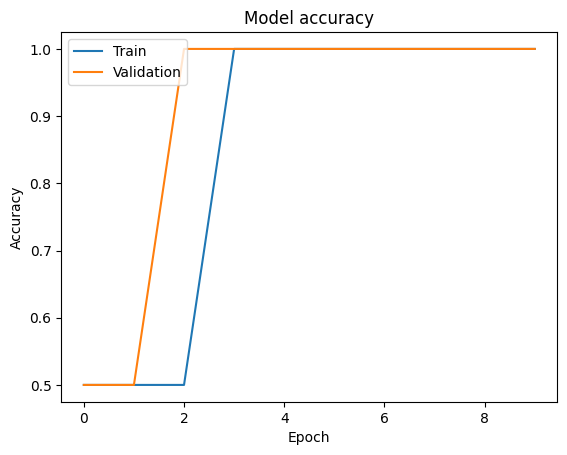

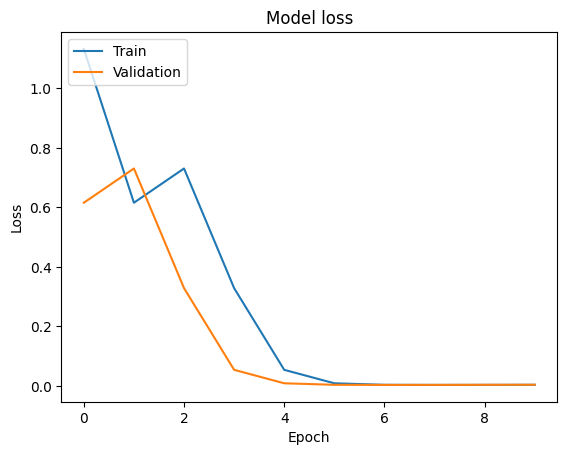

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(r.history['accuracy'])
plt.plot(r.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(r.history['loss'])
plt.plot(r.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
from tensorflow.keras.models import load_model
model.save('model_inception.h5')


In [ ]:
y_pred = model.predict(test_set)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [ ]:
y_pred

array([[3.9496135e-06, 9.9999601e-01],
       [9.9302220e-01, 6.9777477e-03],
       [9.9302220e-01, 6.9777477e-03],
       [3.9496135e-06, 9.9999601e-01],
       [9.9302220e-01, 6.9777477e-03],
       [9.9302220e-01, 6.9777477e-03],
       [3.9496135e-06, 9.9999601e-01],
       [3.9496135e-06, 9.9999601e-01],
       [9.9302226e-01, 6.9777481e-03],
       [3.9496140e-06, 9.9999607e-01]], dtype=float32)

In [ ]:
import numpy as np
y_pred = np.argmax(y_pred, axis=1)

In [ ]:
y_pred

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 1])

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [ ]:
model=load_model('/content/model_inception.h5')

In [ ]:
from keras.preprocessing.image import img_to_array,load_img
import matplotlib.pyplot as plt
import cv2
%matplotlib inline
def pred(img_path):
    img = load_img(img_path,target_size = (224,224)) #Load the image and set the target size to the size of input of our model
    x = img_to_array(img) #Convert the image to array
    x = np.expand_dims(x,axis=0) #Convert the array to the form (1,x,y,z)
    x = preprocess_input(x) # Use the preprocess input function o subtract the mean of all the images
    p = np.argmax(model.predict(x)) # Store the argmax of the predictions
    if p==0:     # P=0 for basal,P=1 for melanoma , P=2 for squamous
        print("Sorry!! You've enetered Irrelevent Data")
    elif p==1:
        print("Moderate Pollution")
    elif p==2:
        print("No Pollution")
    elif p==3:
        print("Severe Pollution")

In [ ]:
import cv2
import glob

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Moderate Pollution


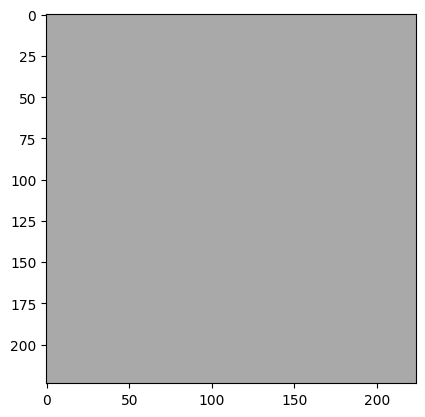

In [ ]:
pred('/content/polluted_test_2.jpg')
z = plt.imread('/content/polluted_test_2.jpg')
plt.imshow(z);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Moderate Pollution


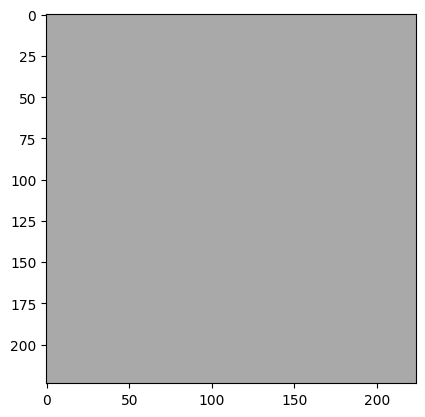

In [ ]:
pred('/content/polluted_test_3.jpg')
z = plt.imread('/content/polluted_test_3.jpg')
plt.imshow(z);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
Sorry!! You've enetered Irrelevent Data


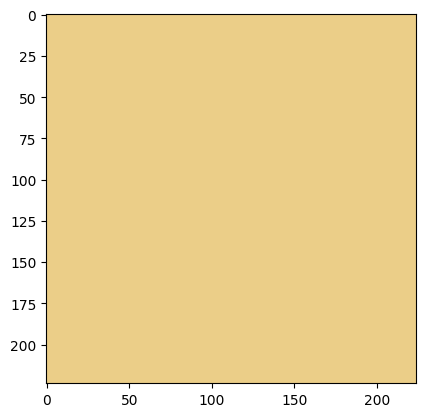

In [ ]:
pred('/content/clean_test_4.jpg')
z = plt.imread('/content/clean_test_4.jpg')
plt.imshow(z);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
Moderate Pollution


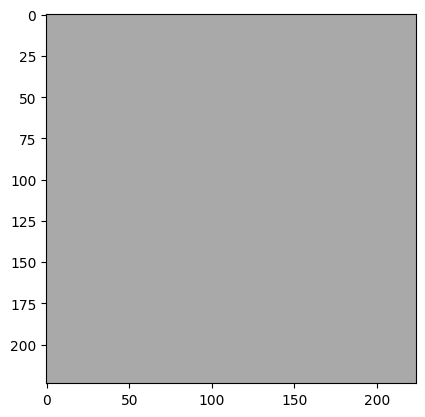

In [ ]:
pred('/content/polluted_test_2.jpg')
z = plt.imread('/content/polluted_test_2.jpg')
plt.imshow(z);

In [ ]:
print(test_set.classes)  # True class labels
print(len(test_set.classes))  # Total number of samples in the test set


[0 0 0 0 0 1 1 1 1 1]
10


In [ ]:
y_pred = model.predict(test_set)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [ ]:
import numpy as np

# Extract predicted class labels
y_pred_classes = np.argmax(y_pred, axis=1)


In [ ]:
# True class labels
y_true = test_set.classes

# Calculate accuracy
accuracy_manual = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"Manual Test Accuracy: {accuracy_manual}")


Manual Test Accuracy: 0.4


In [ ]:
loss, accuracy = model.evaluate(test_set, verbose=1)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 1.0000 - loss: 6.6761e-04
Test Loss: 0.0006676053162664175
Test Accuracy: 1.0


In [ ]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(y_true, y_pred_classes, target_names=test_set.class_indices.keys())
print(report)


              precision    recall  f1-score   support

       clean       0.40      0.40      0.40         5
    polluted       0.40      0.40      0.40         5

    accuracy                           0.40        10
   macro avg       0.40      0.40      0.40        10
weighted avg       0.40      0.40      0.40        10

